<a href="https://colab.research.google.com/github/shardas06543/Master-s-Thesis/blob/main/Fine_Tune_RoBERTa_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning RoBERTa: Broad Based Sentiment Analysis

**The research objectives of this file include the following:**


*   How do different proportions of mixed and synthetic data affect the results of broad-based sentiment analysis, using RoBERTa?
*   Combine the real + synthetic data (in a seperate file), then lightly preprocess, and save to a CSV file




**This file includes the following sections:**


*   Fine-tuning RoBERTa
*   Implementing RoBERTa (not fine-tuned) for broad-based sentiment analysis only


**How will this information be used?**


*  Compare to popular benchmarks from other models (list them here)


1.   State of the art performance benchmarks include F1 score exceeding 0.95




*Should I use a different model other than RoBERTa, if those outperform this one?*











In [ ]:
!pip install emojis

In [ ]:
# Import all required libraries
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from transformers import TrainingArguments, Trainer
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from scipy.special import softmax
from datasets import Dataset # Import Dataset to create Hugging Face objects. Include the source for this?
import re
from bs4 import BeautifulSoup
import string
from sklearn.model_selection import train_test_split
import duckdb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score, confusion_matrix, recall_score, precision_score, average_precision_score, precision_recall_curve, precision_recall_fscore_support
import seaborn as sns

# How do I integrate GPU - is it being used for paraellization? How is it being implemented?

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Preprocessing Synthetic Data**

In [ ]:
def preprocess_text(text):

  # Step 1 - Remove all of the HTML tags (if any)
  soup = BeautifulSoup(text, 'html.parser')
  processed_text = soup.get_text(strip = True) #strip = True removes all leading and trailing whitespace characters

  # Step 2 - convert all the text into lowercase
  lowercase_preprocessed = processed_text.lower()

  # Step 4 - remove all unwanted characters that are not a-z, 0-9,
  # In the report, for all of the functions that we cannot use, explain the rationale in the Thesis report
  cleaned_preprocessed = re.sub(r'(.)\1+', r'\1', text) # This removes duplicate characters / excessive punctuation (for ex: gooood --> good, !!! --> !)
  cleaned_preprocessed = re.sub(r'\s+', ' ', text).strip()

  return cleaned_preprocessed


In [ ]:
# train_url = "https://docs.google.com/spreadsheets/d/1y6uN8fmNnY96-NHhtuargCdWndCMyPxidAN33i8ALsk/export?format=csv&gid=1323181601"
train_url = "/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/train_100%_real.csv"
train_dataset_real = pd.read_csv(train_url)
train_dataset = train_dataset_real[train_dataset_real['Review'] != '']

# # Filter out 'Neutral' sentiment for binary classification
train_dataset = train_dataset[train_dataset['Ground Truth'].str.strip() != 'Neutral']

val_dataset = pd.read_csv("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/validate_real_data_only.csv")
# Filter out 'Neutral' sentiment for binary classification
val_dataset = val_dataset[val_dataset['Ground Truth'].str.strip() != 'Neutral']

test_dataset = pd.read_csv("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/test_real.csv")
# Filter out 'Neutral' sentiment for binary classification
test_dataset = test_dataset[test_dataset['Ground Truth'].str.strip() != 'Neutral']

In [ ]:
# url = "https://docs.google.com/spreadsheets/d/10up--tCc819KUoIoMX62bFW_6TKbLQWxQqukgApR_mY/export?format=csv&gid=0"
# train = pd.read_csv(url)
# train_dataset = train[train['Review'] != '']

In [ ]:
# Preprocess the reviews
# We added fillna due to a TypeError on the dataset
train_dataset["Review"] = train_dataset["Review"].fillna('').apply(preprocess_text)
val_dataset["Review"] = val_dataset["Review"].fillna('').apply(preprocess_text)
test_dataset["Review"] = test_dataset["Review"].fillna('').apply(preprocess_text)

**Fine-Tuning RoBERTa (multi-classification model)**

In [ ]:
# RobERTa from - from Hugging Face (trained on Twitter)
# MODEL_name = f"cardiffnlp/twitter-roberta-base-sentiment-latest"

# MODEL = AutoModelForSequenceClassification.from_pretrained(MODEL_name)

# tokenizer = AutoTokenizer.from_pretrained(MODEL_name)

In [ ]:
# # Load the id2label and label2id (note - this is a multi-classification problem)

# # NOTE - We are creating a "multi-classification head" -->
# # NOTE - mention this as a small step in the thesis report as part of the process for fine-tuning using a transfer learning approach
# id2label = {0: "Negative", 1:"Neutral", 2:"Positive"}
# label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}


# # # Create the new model
# model_multi = AutoModelForSequenceClassification.from_pretrained(MODEL_name, num_labels = 3,
#                                                                   id2label = id2label,
#                                                                   label2id = label2id)

# # # Training parameters (use a "transfer learning" approach b/c we are freezing all of the model parameters except for the last 4 layers)
# # # step 1 - Freeze all of the parameters which are not in the new multi-classification head defined above
# for param in model_multi.base_model.parameters():
#   param.requires_grad = False

# # # step 2 - unfreeze any layers with the name "pooler" within it - these parameters are going to be used in the fine-tuning process
# for name, param in model_multi.base_model.named_parameters():
#  if "pooler" in name:
#    param.requires_grad = True

# # # Step 3 - Tokenization function for the Dataset. We are aiming to convert the text data into a read-able format for the RoBERTa archiecture to use
# # # NOTE - Within this function, we are NOT padding or returning the tensors as we originally did when we did not use fine-tuning.
# # # NOTE - We are returning the input_ids and the attention_mask (COME BACK HERE)
# def tokenize_function(examples):

#     tokenized_inputs = tokenizer(examples["Review"], truncation=True, max_length=512)

# #    # This line makes sense because when we do (**encoded_text) without fine-tuning, we are getting input_ids and attention mask
#     return {
#         'input_ids': tokenized_inputs['input_ids'],
#         'attention_mask': tokenized_inputs['attention_mask']
#     }

**Binary classification model**

We implement a different model for this step from Hugging Face:


In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer

model_name = "AnkitAI/reviews-roberta-base-sentiment-analysis"
model = RobertaForSequenceClassification.from_pretrained(model_name)
tokenizer = RobertaTokenizer.from_pretrained(model_name)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Load the id2label and label2id (note - this is a binary classification problem)

# NOTE - We are creating a "binary-classification head" -->
# NOTE - mention this as a small step in the thesis report as part of the process for fine-tuning using a transfer learning approach
id2label = {0: "Negative", 1:"Positive"}
label2id = {"Negative": 0, "Positive": 1}


# Create the new model
model_multi = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = 2,
                                                                 id2label = id2label,
                                                                 label2id = label2id,
                                                                 ignore_mismatched_sizes=True)

# Training parameters (use a "transfer learning" approach b/c we are freezing all of the model parameters except for the last 4 layers)
# step 1 - Freeze all of the parameters which are not in the new multi-classification head defined above
for param in model_multi.base_model.parameters():
  param.requires_grad = False #

# step 2 - unfreeze any layers with the name "pooler" within it - these parameters are going to be used in the fine-tuning process
for name, param in model_multi.base_model.named_parameters():
  if "pooler" in name:
    param.requires_grad = True

# Step 3 - Tokenization function for the Dataset. We are aiming to convert the text data into a read-able format for the RoBERTa archiecture to use
   # SOURCE: We also leveraged the "code-fixing" feature offered by Google Collab Notebook for the fine-tuning step - (mentioning this for transparency.)

# NOTE - Within this function, we are NOT padding or returning the tensors as we originally did when we did not use fine-tuning.
# NOTE - We are returning the input_ids and the attention_mask (COME BACK HERE)
def tokenize_function(examples):

    tokenized_inputs = tokenizer(examples["Review"], truncation=True, max_length=512)

    # This line makes sense because when we do (**encoded_text) without fine-tuning, we are getting input_ids and attention mask
    return {
        'input_ids': tokenized_inputs['input_ids'],
        'attention_mask': tokenized_inputs['attention_mask']
    }

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

**Convert the datasets to Hugging Face objects so they can be passed to Trainer and Training Args**


In [ ]:
train_dataset_filtered = train_dataset[train_dataset['Ground Truth'].str.strip() != 'Neutral'].copy()
val_dataset_filtered = val_dataset[val_dataset['Ground Truth'].str.strip() != 'Neutral'].copy()
test_dataset_filtered = test_dataset[test_dataset['Ground Truth'].str.strip() != 'Neutral'].copy()

train_labels = train_dataset_filtered["Ground Truth"].str.strip().apply(lambda x: label2id[x]).tolist() # Convert string labels to integer IDs
val_labels = val_dataset_filtered["Ground Truth"].str.strip().apply(lambda x: label2id[x]).tolist() # Convert string labels to integer IDs
test_labels = test_dataset_filtered["Ground Truth"].str.strip().apply(lambda x: label2id[x]).tolist() # Convert string labels to integer IDs

In [ ]:
# Step 5 - Convert the datasets to hugging face objects because data_collator only operates on this
train_dataset = Dataset.from_dict({'Review': train_dataset_filtered["Review"], 'labels': train_labels})
val_dataset = Dataset.from_dict({'Review': val_dataset_filtered["Review"], 'labels': val_labels})
test_dataset = Dataset.from_dict({'Review': test_dataset_filtered["Review"], 'labels': test_labels})

**Tokenize the train and validation datasets**

In [ ]:
# Step 6 - Apply the tokenization function to the datasets
# batched = True --> this parameter indicates that the tokenize function does not run each value one at a time and instead runs in batches for faster runtime
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

#print(type(tokenized_train_dataset)) # This is of type: <class 'datasets.arrow_dataset.Dataset'>


Map:   0%|          | 0/1596 [00:00<?, ? examples/s]

Map:   0%|          | 0/214 [00:00<?, ? examples/s]

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

In [ ]:
os.environ["WANDB_DISABLED"] = "true"

**Define metrics to be computed by the Trainer function**

In [ ]:
def evaluate_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1) # NOTE - axis = -1

  macro_f1 = f1_score(labels, predictions, average='macro')
  bal_acc = balanced_accuracy_score(labels, predictions)
  confusion_mat = confusion_matrix(labels, predictions).tolist()


  macro_recall = recall_score(labels, predictions, average = 'macro')
  macro_precision = precision_score(labels, predictions, average = 'macro')
  precision, recall, f1, support = precision_recall_fscore_support(
    labels, predictions, average=None
)

  per_class_metrics = {}
  num_classes = 2 # Changed to 2 for binary classification
  class_names = list(id2label.values())


  for i, cls_name in enumerate(class_names):
        per_class_metrics[cls_name] = {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1": float(f1[i]),
            "support": int(support[i])
        }


  return {
          "per_class_metrics": per_class_metrics,
          "macro_f1": macro_f1,
          "balanced_accuracy": bal_acc,
          "confusion_matrix": confusion_mat,
          "macro_precision":macro_precision,
          "macro_recall":macro_recall
          }

**Hyperparameter Tuning**

In [ ]:
# Step 8 - use a data collator to ensure uniform length for batches
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Step 9 - set the hyperparameters
learning_rate = 2e-5
batch_size = 8 # NOTE - I chose this number based on the given youtube video as a starting point
num_epochs = 10 # NOTE - I chose this number based on the given youtube video as a starting point
output_dir = "/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/roberta_code/binary_baseline"

training_param = TrainingArguments(
    output_dir = output_dir,
    learning_rate = learning_rate,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    num_train_epochs = num_epochs,
    logging_strategy = "epoch",
    eval_strategy = "epoch",
    save_strategy = "epoch", # This means the model saves at every epoch
    load_best_model_at_end=True, # The model loads the version that was at the best epoch (so the lowest validation and training loss)
    greater_is_better=False,
    metric_for_best_model="eval_loss" #Take the model with the lowest validation loss



)

trainer = Trainer(
    model = model_multi,
    args = training_param,
    train_dataset = tokenized_train_dataset,
    eval_dataset = tokenized_val_dataset, #This is the dev dataset
    data_collator = data_collator,
    compute_metrics = evaluate_metrics
)

In [ ]:
trainer.train()

# In report - define what loss function is being used to calculate training and validation loss

Epoch,Training Loss,Validation Loss,Per Class Metrics,Macro F1,Balanced Accuracy,Confusion Matrix,Macro Precision,Macro Recall
1,0.148021,0.077057,"{'Negative': {'precision': 1.0, 'recall': 0.9393939393939394, 'f1': 0.96875, 'support': 99}, 'Positive': {'precision': 0.9504132231404959, 'recall': 1.0, 'f1': 0.9745762711864406, 'support': 115}}",0.971663,0.969697,"[[93, 6], [0, 115]]",0.975207,0.969697
2,0.134323,0.071466,"{'Negative': {'precision': 1.0, 'recall': 0.9494949494949495, 'f1': 0.9740932642487047, 'support': 99}, 'Positive': {'precision': 0.9583333333333334, 'recall': 1.0, 'f1': 0.9787234042553191, 'support': 115}}",0.976408,0.974747,"[[94, 5], [0, 115]]",0.979167,0.974747
3,0.132627,0.066341,"{'Negative': {'precision': 1.0, 'recall': 0.9595959595959596, 'f1': 0.979381443298969, 'support': 99}, 'Positive': {'precision': 0.9663865546218487, 'recall': 1.0, 'f1': 0.9829059829059829, 'support': 115}}",0.981144,0.979798,"[[95, 4], [0, 115]]",0.983193,0.979798
4,0.132749,0.066876,"{'Negative': {'precision': 1.0, 'recall': 0.9595959595959596, 'f1': 0.979381443298969, 'support': 99}, 'Positive': {'precision': 0.9663865546218487, 'recall': 1.0, 'f1': 0.9829059829059829, 'support': 115}}",0.981144,0.979798,"[[95, 4], [0, 115]]",0.983193,0.979798
5,0.144065,0.066326,"{'Negative': {'precision': 1.0, 'recall': 0.9595959595959596, 'f1': 0.979381443298969, 'support': 99}, 'Positive': {'precision': 0.9663865546218487, 'recall': 1.0, 'f1': 0.9829059829059829, 'support': 115}}",0.981144,0.979798,"[[95, 4], [0, 115]]",0.983193,0.979798
6,0.134268,0.066247,"{'Negative': {'precision': 1.0, 'recall': 0.9595959595959596, 'f1': 0.979381443298969, 'support': 99}, 'Positive': {'precision': 0.9663865546218487, 'recall': 1.0, 'f1': 0.9829059829059829, 'support': 115}}",0.981144,0.979798,"[[95, 4], [0, 115]]",0.983193,0.979798
7,0.138908,0.065238,"{'Negative': {'precision': 0.9895833333333334, 'recall': 0.9595959595959596, 'f1': 0.9743589743589743, 'support': 99}, 'Positive': {'precision': 0.9661016949152542, 'recall': 0.991304347826087, 'f1': 0.9785407725321889, 'support': 115}}",0.976450,0.975450,"[[95, 4], [1, 114]]",0.977843,0.975450
8,0.139852,0.065654,"{'Negative': {'precision': 1.0, 'recall': 0.9595959595959596, 'f1': 0.979381443298969, 'support': 99}, 'Positive': {'precision': 0.9663865546218487, 'recall': 1.0, 'f1': 0.9829059829059829, 'support': 115}}",0.981144,0.979798,"[[95, 4], [0, 115]]",0.983193,0.979798
9,0.131559,0.065934,"{'Negative': {'precision': 1.0, 'recall': 0.9595959595959596, 'f1': 0.979381443298969, 'support': 99}, 'Positive': {'precision': 0.9663865546218487, 'recall': 1.0, 'f1': 0.9829059829059829, 'support': 115}}",0.981144,0.979798,"[[95, 4], [0, 115]]",0.983193,0.979798
10,0.138046,0.065898,"{'Negative': {'precision': 1.0, 'recall': 0.9595959595959596, 'f1': 0.979381443298969, 'support': 99}, 'Positive': {'precision': 0.9663865546218487, 'recall': 1.0, 'f1': 0.9829059829059829, 'support': 115}}",0.981144,0.979798,"[[95, 4], [0, 115]]",0.983193,0.979798


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2000, training_loss=0.13744169521331787, metrics={'train_runtime': 341.376, 'train_samples_per_second': 46.752, 'train_steps_per_second': 5.859, 'total_flos': 2268144741620640.0, 'train_loss': 0.13744169521331787, 'epoch': 10.0})

In [ ]:
# This gets the model at the epoch with the lowest training and validation loss
trainer.state.best_model_checkpoint

'/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/roberta_code/binary_baseline/checkpoint-1400'

**Get the trainer and validation loss (to demonstrate the fine-tuning process in the model)**

In [ ]:
# source:
log_history = trainer.state.log_history
log_history
epochs = [x for x in range(1, 11)]

# NOTE - train_loss is equivalent to "loss" and validation loss is "eval_loss"
train_losses = [log['loss'] for log in log_history if 'loss' in log]
val_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
# The test loss is not being recorded per epoch


In [ ]:
# In the report - chart the values of the fine-tuning process.
log_df = pd.DataFrame(trainer.state.log_history)
#log_df.to_csv("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Fine_Tune_Performance_0%_real_neutral.csv", index=False)


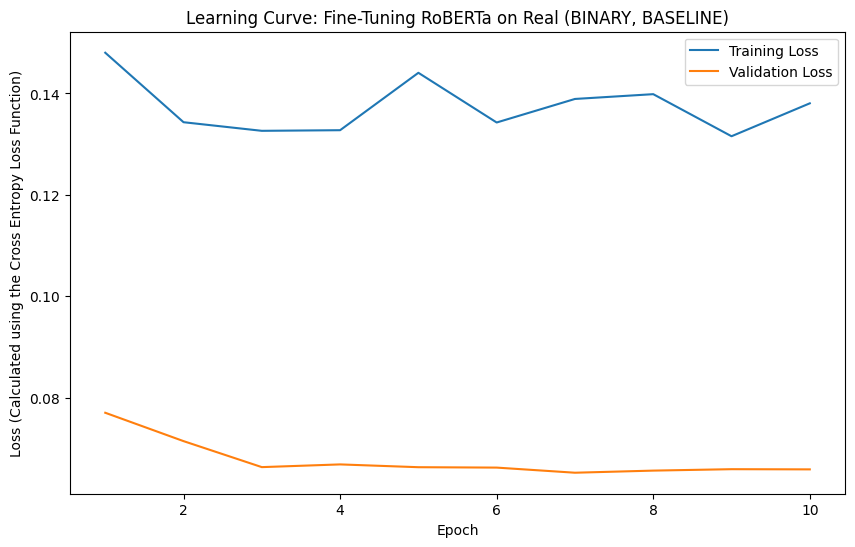

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Calculated using the Cross Entropy Loss Function)')
plt.title('Learning Curve: Fine-Tuning RoBERTa on Real (BINARY, BASELINE)')
plt.legend()
plt.savefig("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Figures/Fine_Tune_Learning_Curve_BINARY_BASELINE.png")

**Evaluate the fine-tune model on test dataset**

In [ ]:
checkpoint_path = trainer.state.best_model_checkpoint
print(checkpoint_path)
trainer.evaluate(tokenized_test_dataset, metric_key_prefix="test") #metric_key_prefix = "test" will append test to the column names printed
# trainer.evaluate does not produce results for each epoch. It provides a snapshot only

/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/roberta_code/binary_baseline/checkpoint-1400


{'test_loss': 0.11257584393024445,
 'test_per_class_metrics': {'Negative': {'precision': 0.9747899159663865,
   'recall': 0.9586776859504132,
   'f1': 0.9666666666666667,
   'support': 242},
  'Positive': {'precision': 0.9606299212598425,
   'recall': 0.976,
   'f1': 0.9682539682539683,
   'support': 250}},
 'test_macro_f1': 0.9674603174603175,
 'test_balanced_accuracy': 0.9673388429752066,
 'test_confusion_matrix': [[232, 10], [6, 244]],
 'test_macro_precision': 0.9677099186131145,
 'test_macro_recall': 0.9673388429752066,
 'test_runtime': 7.5542,
 'test_samples_per_second': 65.129,
 'test_steps_per_second': 8.207,
 'epoch': 10.0}

**Get confusion matrix**

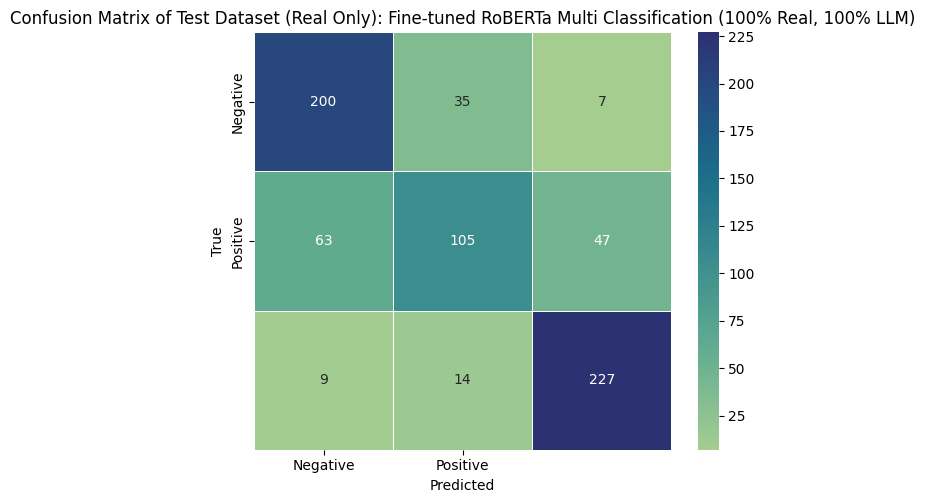

In [ ]:
#m = np.array([[200, 35, 7], [63, 105, 47], [9, 14, 227]]) # Updated to reflect the binary confusion matrix from the evaluation results

# Define classes using the global id2label dictionary
classes = list(id2label.values())

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="crest",
    linewidths=0.5,
    square=True,
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix of Test Dataset (Real Only): Fine-tuned RoBERTa Multi Classification (100% Real, 100% LLM)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Figures/Confusion Matrix_100%_LLM+real.png", bbox_inches="tight", dpi=300)
plt.show()